# LOAD LIBRARIES

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [16]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'time_blocks_eliza'
N_FOLDS = 10
PARCEL_CERTAIN = False # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = True
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True

# LOAD DATA

In [17]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))
    print("\nAdded 'id' variable --> indexing number starting from zero")
else:
    print('\nNot using index variable')

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.721 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Added 'id' variable --> indexing number starting from zero


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,RECO_NT_CUT_50_gfXG_parcelA_all,GPP_NT_CUT_50_gfXG_parcelA_all,RECO_NT_CUT_50_gfXG_parcelB_all,...,RECO_NT_CUT_50_gfXG_all_lag6h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_all_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll9hsum,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,B,certain,1.0,0.0,2.582962,2.582962,2.071689,-0.511273,2.071689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,B,certain,1.0,0.0,2.624325,2.624325,2.110065,-0.514260,2.110065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,B,certain,1.0,0.0,2.530318,2.530318,2.102006,-0.428313,2.102006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,B,certain,1.0,0.0,2.496630,2.496630,2.104021,-0.392608,2.104021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,B,certain,1.0,0.0,2.385376,2.385376,2.097972,-0.287404,2.097972,...,NaN,NaN,NaN,NaN,NaN,-0.133015,-0.133015,-0.133015,NaN,NaN,NaN,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,8.363036,8.363036,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27643
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,8.207649,8.207649,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,8.700291,8.700291,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27645


# CLEAN DATA

In [18]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}\n')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("Mean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

data

The target variable is FN2O_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 4.75503355704698

Keeping also data from mixed parcel contribution


,NEE_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,RECO_NT_CUT_50_gfXG_parcelA_all,GPP_NT_CUT_50_gfXG_parcelA_all,RECO_NT_CUT_50_gfXG_parcelB_all,GPP_NT_CUT_50_gfXG_parcelB_all,...,RECO_NT_CUT_50_gfXG_all_lag6h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_all_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll9hsum,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:45:00,NaN,NaN,NaN,0.100302,NaN,B,certain,1.0,0.0,2.624325,2.624325,2.110065,-0.514260,2.110065,-0.514260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2023-11-08 01:15:00,NaN,NaN,NaN,0.239428,NaN,B,certain,1.0,0.0,2.530318,2.530318,2.102006,-0.428313,2.102006,-0.428313,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2023-11-08 02:15:00,NaN,3.168362,NaN,0.358358,3.168362,B,certain,1.0,0.0,2.385376,2.385376,2.097972,-0.287404,2.097972,-0.287404,...,NaN,NaN,NaN,NaN,NaN,-0.133015,-0.133015,-0.133015,NaN,NaN,NaN,NaN,NaN,NaN,4
2023-11-08 03:15:00,NaN,-3.270484,NaN,0.070120,-3.270484,B,certain,1.0,0.0,2.215443,2.215443,2.075740,-0.139703,2.075740,-0.139703,...,NaN,NaN,NaN,NaN,NaN,-0.776316,-0.776316,-0.776316,NaN,NaN,NaN,NaN,NaN,NaN,6
2023-11-08 04:15:00,NaN,NaN,NaN,-0.545573,NaN,B,certain,1.0,0.0,1.912208,1.912208,2.029001,0.116793,2.029001,0.116793,...,NaN,NaN,NaN,NaN,NaN,-1.718889,-1.718889,-1.718889,NaN,NaN,NaN,NaN,NaN,NaN,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:15:00,10.359786,2.715553,10.359786,0.282174,NaN,B,certain,1.0,0.0,10.359786,10.359786,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27594
2025-06-04 21:45:00,10.578562,2.489636,10.578562,0.524032,NaN,B,certain,1.0,0.0,10.578562,10.578562,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27595
2025-06-04 22:45:00,10.095010,2.160966,10.095010,-0.069384,2.160966,B,certain,1.0,0.0,10.095010,10.095010,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27597


# SELECT FEATURES

In [19]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data


The treatment variable (trt) is included in the feature set


,timesince_soil_preparation,timesince_harvest,timesince_sowing,wfps_0.05_gfXG_lag9h,wfps_0.05_gfXG_roll3hmean,ts_0.3_gfXG_lag6h_roll9hmean,wfps_0.15_gfXG_lag3h_roll6hmean,wfps_0.15_gfXG_lag9h_roll9hmean,n_decay_lognormal,LAI,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2023-11-08 00:45:00,21.0,22.0,21.0,45.247686,46.457919,11.147678,55.265361,55.268951,0.983564,0.300704,1,1.0,0.100302
2023-11-08 01:15:00,21.0,22.0,21.0,45.215566,46.203886,11.119251,55.248801,55.264551,0.980476,0.300709,2,1.0,0.239428
2023-11-08 02:15:00,21.0,22.0,21.0,45.038043,45.930307,11.073098,55.237824,55.244826,0.974334,0.300718,4,1.0,0.358358
2023-11-08 03:15:00,21.0,22.0,21.0,47.646389,45.870280,11.029898,55.222109,55.238288,0.968238,0.300727,6,1.0,0.070120
2023-11-08 04:15:00,21.0,22.0,21.0,47.833587,45.867461,11.016731,55.205581,55.247042,0.962185,0.300737,8,1.0,-0.545573
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:15:00,60.0,23.0,60.0,48.539355,47.838889,16.984228,49.902567,50.266203,0.000000,4.385766,27594,1.0,0.282174
2025-06-04 21:45:00,60.0,23.0,60.0,48.430304,47.840280,16.980679,49.884240,50.247451,0.000000,4.389574,27595,1.0,0.524032
2025-06-04 22:45:00,60.0,23.0,60.0,48.234481,47.842013,16.985123,49.852705,50.203644,0.000000,4.397189,27597,1.0,-0.069384


# IMBALANCE HANDLING

## UNDER SAMPLING

In [20]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling');
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

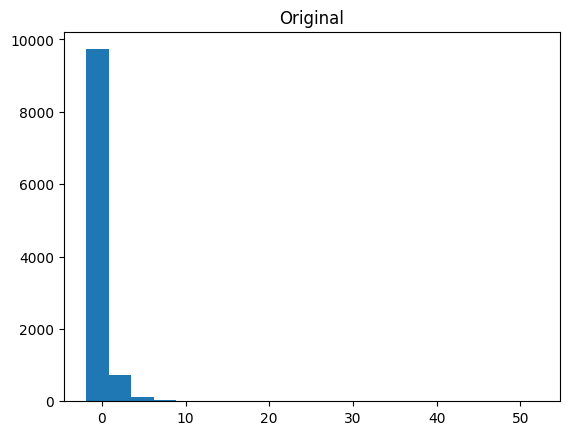

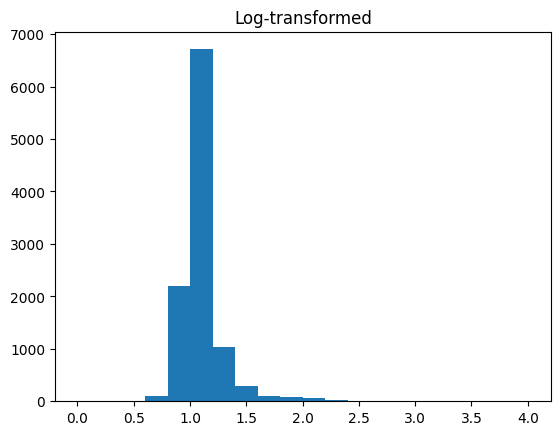

Log-tranformed
FN2O_L3.3_CUT_50_QCF0 was log-transformed


,timesince_soil_preparation,timesince_harvest,timesince_sowing,wfps_0.05_gfXG_lag9h,wfps_0.05_gfXG_roll3hmean,ts_0.3_gfXG_lag6h_roll9hmean,wfps_0.15_gfXG_lag3h_roll6hmean,wfps_0.15_gfXG_lag9h_roll9hmean,n_decay_lognormal,LAI,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2023-11-08 00:45:00,21.0,22.0,21.0,45.247686,46.457919,11.147678,55.265361,55.268951,0.983564,0.300704,1,1.0,1.088437
2023-11-08 01:15:00,21.0,22.0,21.0,45.215566,46.203886,11.119251,55.248801,55.264551,0.980476,0.300709,2,1.0,1.134222
2023-11-08 02:15:00,21.0,22.0,21.0,45.038043,45.930307,11.073098,55.237824,55.244826,0.974334,0.300718,4,1.0,1.171765
2023-11-08 03:15:00,21.0,22.0,21.0,47.646389,45.870280,11.029898,55.222109,55.238288,0.968238,0.300727,6,1.0,1.078221
2023-11-08 04:15:00,21.0,22.0,21.0,47.833587,45.867461,11.016731,55.205581,55.247042,0.962185,0.300737,8,1.0,0.843184
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:15:00,60.0,23.0,60.0,48.539355,47.838889,16.984228,49.902567,50.266203,0.000000,4.385766,27594,1.0,1.147879
2025-06-04 21:45:00,60.0,23.0,60.0,48.430304,47.840280,16.980679,49.884240,50.247451,0.000000,4.389574,27595,1.0,1.221820
2025-06-04 22:45:00,60.0,23.0,60.0,48.234481,47.842013,16.985123,49.852705,50.203644,0.000000,4.397189,27597,1.0,1.029599


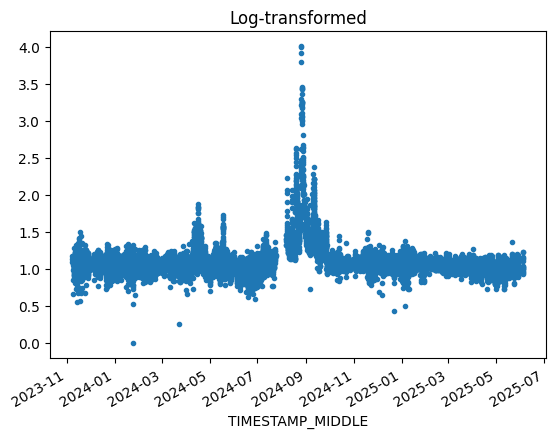

In [21]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (6 records on average) splits for cross-validation



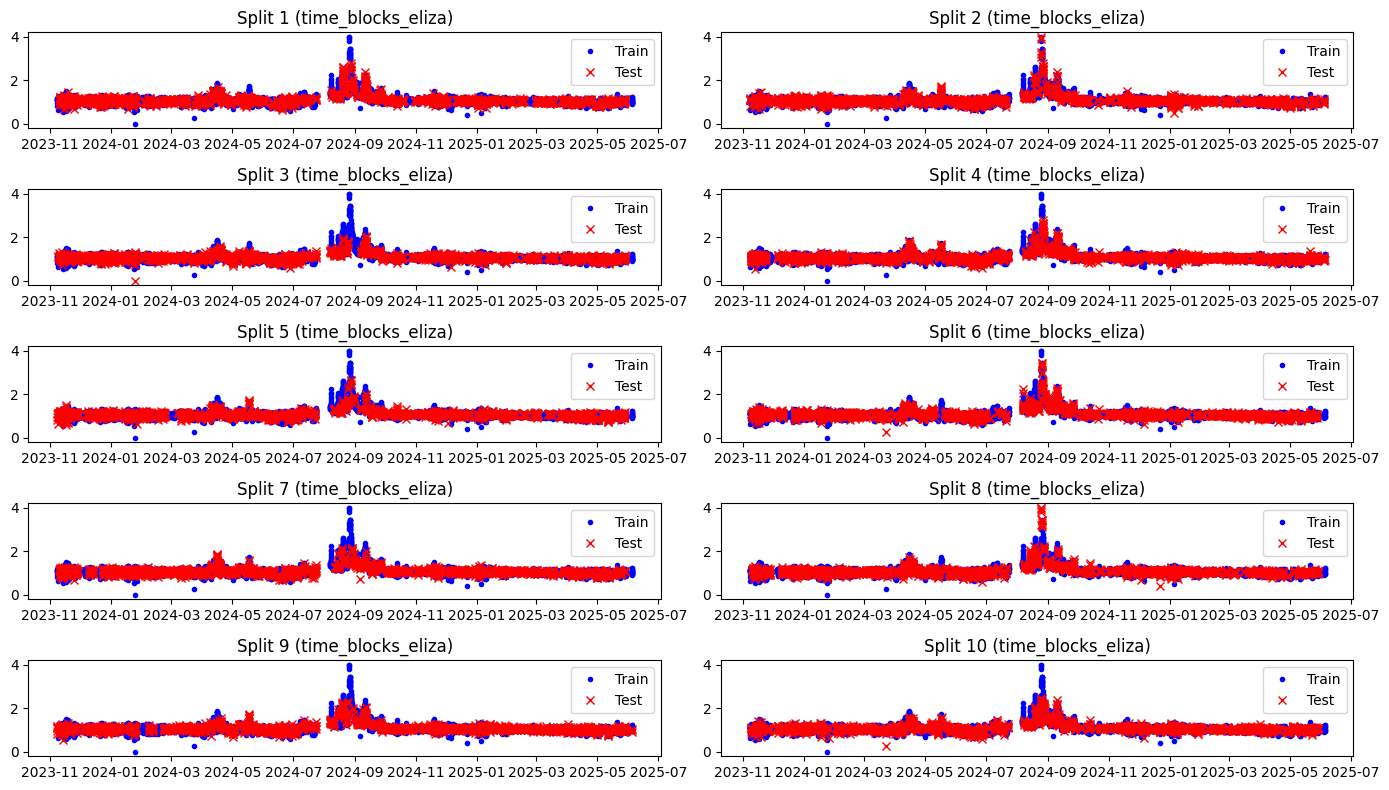

In [22]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 6 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [18]:
# Convert cross-val splits into PredefinedSplit format to be able to use them in GridSearchCV
test_fold = np.full(len(data), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(cross_val_splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
predefined_cv = PredefinedSplit(test_fold)

param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 300, 500], # Similar to XGBoost
        'max_depth': [3, 5, 10, 15], # Controls tree depth
        'min_samples_split': [2, 5, 10], # Similar to min_child_weight
        'min_samples_leaf': [1, 3, 5], # Controls leaf size
        'max_features': [0.4, 0.6, 0.8, 1.0], # Similar to colsample_bytree
    },
    'XGBoost': {
        'n_estimators': [50, 100, 300, 500],
        'gamma': [0, 0.2, 0.4],
        'max_depth': [3, 5, 10, 15],
        'learning_rate': [0.001, 0.005, 0.01, 0.05],
        'subsample': [0.65, 0.75, 1],
        'colsample_bytree': [0.4, 0.6, 0.8, 1],
        'min_child_weight': [2, 5, 10]
    }
}

model_class = RandomForestRegressor if MODEL_TYPE == 'RandomForest' else XGBRegressor
param_grid = param_grids[MODEL_TYPE]
model = model_class(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=predefined_cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(data[selected_features], data[TARGET])

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 2, 'n_estimators': 500, 'subsample': 1}


# EXPORT 

In [19]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(grid_search.best_params_, f)

# **End of notebook**

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-10-24 09:48:55
